# Sales Data Analysis
A data analysis project to explore supermarket sales data and generate business insights using Python.

## Objective 
The objective of this project is to analyze supermarket sales data to understand customer purchasing behavior, identify sales trends, evaluate branch performance, and generate business insights using Python libraries such as Pandas, Matplotlib, and Seaborn.

## Import libraries
The required Python libraries are imported for data manipulation, visualization, and analysis.

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display plots inside Jupyter Notebook
%matplotlib inline


In [4]:
import os

files = os.listdir(r"C:\Users\Mahi Tomer\Downloads")

for file in files:
    if "supermarket" in file.lower():
        print(file)


supermarket_sales.csv


In [8]:
sales = pd.read_csv(r"C:\Users\Mahi Tomer\Downloads\supermarket_sales.csv")

print(sales.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

## Data Cleaning
The dataset is examined for missing values, duplicate records, incorrect data types, and inconsistencies. Necessary preprocessing steps are performed to prepare the data for analysis.

In [5]:
sales.info

<bound method DataFrame.info of       Invoice ID Branch       City Customer type  Gender  \
0    750-67-8428      A     Yangon        Member  Female   
1    226-31-3081      C  Naypyitaw        Normal  Female   
2    631-41-3108      A     Yangon        Normal    Male   
3    123-19-1176      A     Yangon        Member    Male   
4    373-73-7910      A     Yangon        Normal    Male   
..           ...    ...        ...           ...     ...   
995  233-67-5758      C  Naypyitaw        Normal    Male   
996  303-96-2227      B   Mandalay        Normal  Female   
997  727-02-1313      A     Yangon        Member    Male   
998  347-56-2442      A     Yangon        Normal    Male   
999  849-09-3807      A     Yangon        Member  Female   

               Product line  Unit price  Quantity   Tax 5%      Total  \
0         Health and beauty       74.69         7  26.1415   548.9715   
1    Electronic accessories       15.28         5   3.8200    80.2200   
2        Home and lifestyle 

In [6]:
sales['date'] = pd.to_datetime(sales['Date'])
sales['date'].dtype

dtype('<M8[us]')

In [7]:
type(sales['date'])

pandas.Series

In [9]:
sales['date'] = pd.to_datetime(sales['date'])

In [12]:
sales['day'] = (sales['date']).dt.day

In [13]:
sales['month'] = (sales['date']).dt.month

In [14]:
sales['year'] = (sales['date']).dt.year

In [15]:
sales['Time'] = pd.to_datetime(sales['Time'])

In [16]:
sales['Hour'] = (sales['Time']).dt.hour

In [17]:
sales['Hour'].nunique()  #gives us the number of unique hours 

11

In [18]:
sales['Hour'].unique()

array([13, 10, 20, 18, 14, 11, 17, 16, 19, 15, 12], dtype=int32)

In [19]:
sales.describe()

,Unit price,Quantity,Tax 5%,Total,Time,cogs,gross margin percentage,gross income,Rating,date,day,month,year,Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.00000,1000,1000.000000,1000.000000,1000.0,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2026-07-28 15:24:41.880000,307.58738,4.761905,15.379369,6.97270,2019-02-14 00:05:45.600000,15.256000,1.993000,2019.0,14.910000
min,10.080000,1.000000,0.508500,10.678500,2026-07-28 10:00:00,10.17000,4.761905,0.508500,4.00000,2019-01-01 00:00:00,1.000000,1.000000,2019.0,10.000000
25%,32.875000,3.000000,5.924875,124.422375,2026-07-28 12:43:00,118.49750,4.761905,5.924875,5.50000,2019-01-24 00:00:00,8.000000,1.000000,2019.0,12.000000
50%,55.230000,5.000000,12.088000,253.848000,2026-07-28 15:19:00,241.76000,4.761905,12.088000,7.00000,2019-02-13 00:00:00,15.000000,2.000000,2019.0,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2026-07-28 18:15:00,448.90500,4.761905,22.445250,8.50000,2019-03-08 00:00:00,23.000000,3.000000,2019.0,18.000000
max,99.960000,10.000000,49.650000,1042.650000,2026-07-28 20:59:00,993.00000,4.761905,49.650000,10.00000,2019-03-30 00:00:00,31.000000,3.000000,2019.0,20.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,0.000000,11.708825,1.71858,NaN,8.693563,0.835254,0.0,3.186857


In [24]:
sales.select_dtypes(include=['number']).columns

Index(['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs',
       'gross margin percentage', 'gross income', 'Rating', 'day', 'month',
       'year', 'Hour'],
      dtype='str')

In [25]:
numeric_columns = [cname for cname in sales.columns if sales[cname].dtype != "object"]
print(numeric_columns)

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating', 'date', 'day', 'month', 'year', 'Hour']


In [27]:
print("# unique values in Branch: {0}".format(len(sales['Branch'].unique().tolist())))
print("# unique values in City: {0}".format(len(sales['City'].unique().tolist())))
print("# unique values in Customer Type: {0}".format(len(sales['Customer type'].unique().tolist())))
print("# unique values in Gender: {0}".format(len(sales['Gender'].unique().tolist())))
print("# unique values in Product Line: {0}".format(len(sales['Product line'].unique().tolist())))
print("# unique values in Payment: {0}".format(len(sales['Payment'].unique().tolist())))

# unique values in Branch: 3
# unique values in City: 3
# unique values in Customer Type: 2
# unique values in Gender: 2
# unique values in Product Line: 6
# unique values in Payment: 3


## EDA (Exploratory Data Analysis)
EDA is performed to understand sales patterns, customer behavior, branch performance, and product demand using various visualizations.

### 1. Gender Distribution (Count Plot)

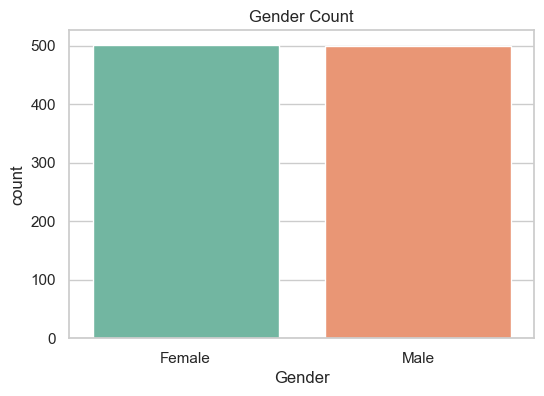

In [33]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Gender",
    hue="Gender",
    data=sales,
    palette="Set2",
    legend=False
)

plt.title("Gender Count")
plt.show()

- The distribution of male and female customers is nearly balanced.
- Both genders contribute almost equally to the total number of transactions.
- This indicates that the supermarket attracts customers from both genders equally.

### 2. Branch vs Rating (Box Plot)

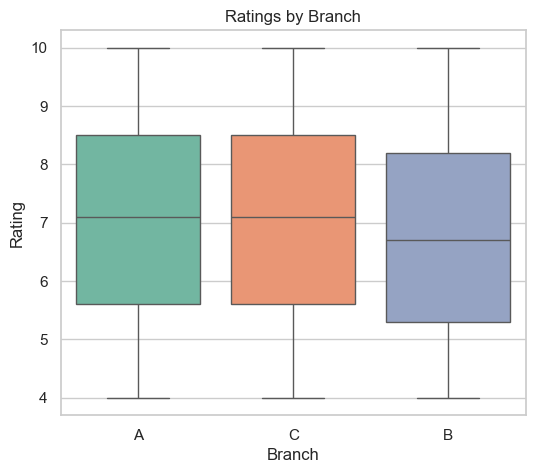

In [34]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Branch",
    y="Rating",
    hue="Branch",
    data=sales,
    palette="Set2",
    legend=False
)

plt.title("Ratings by Branch")
plt.show()

Branch B has the lowest rating among all the branches

### 3. Product Sales per Hour (Line Plot)

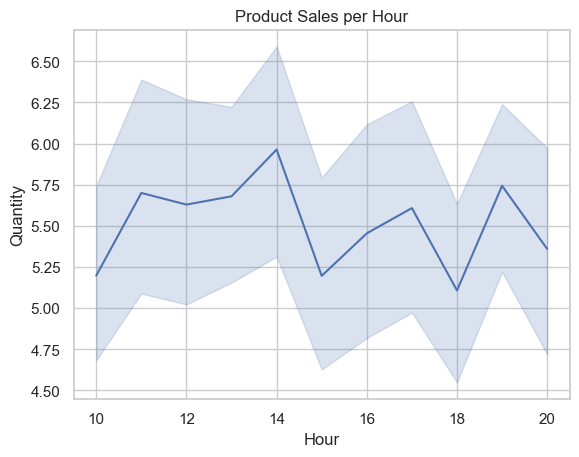

In [35]:
genderCount  = sns.lineplot(x="Hour",  y = 'Quantity',data =sales).set_title("Product Sales per Hour")

Sales by the hour in the company most of the item were sold around 14:00 hrs local time

### 4. Quantity Sold by Hour (Month × Branch × Gender)

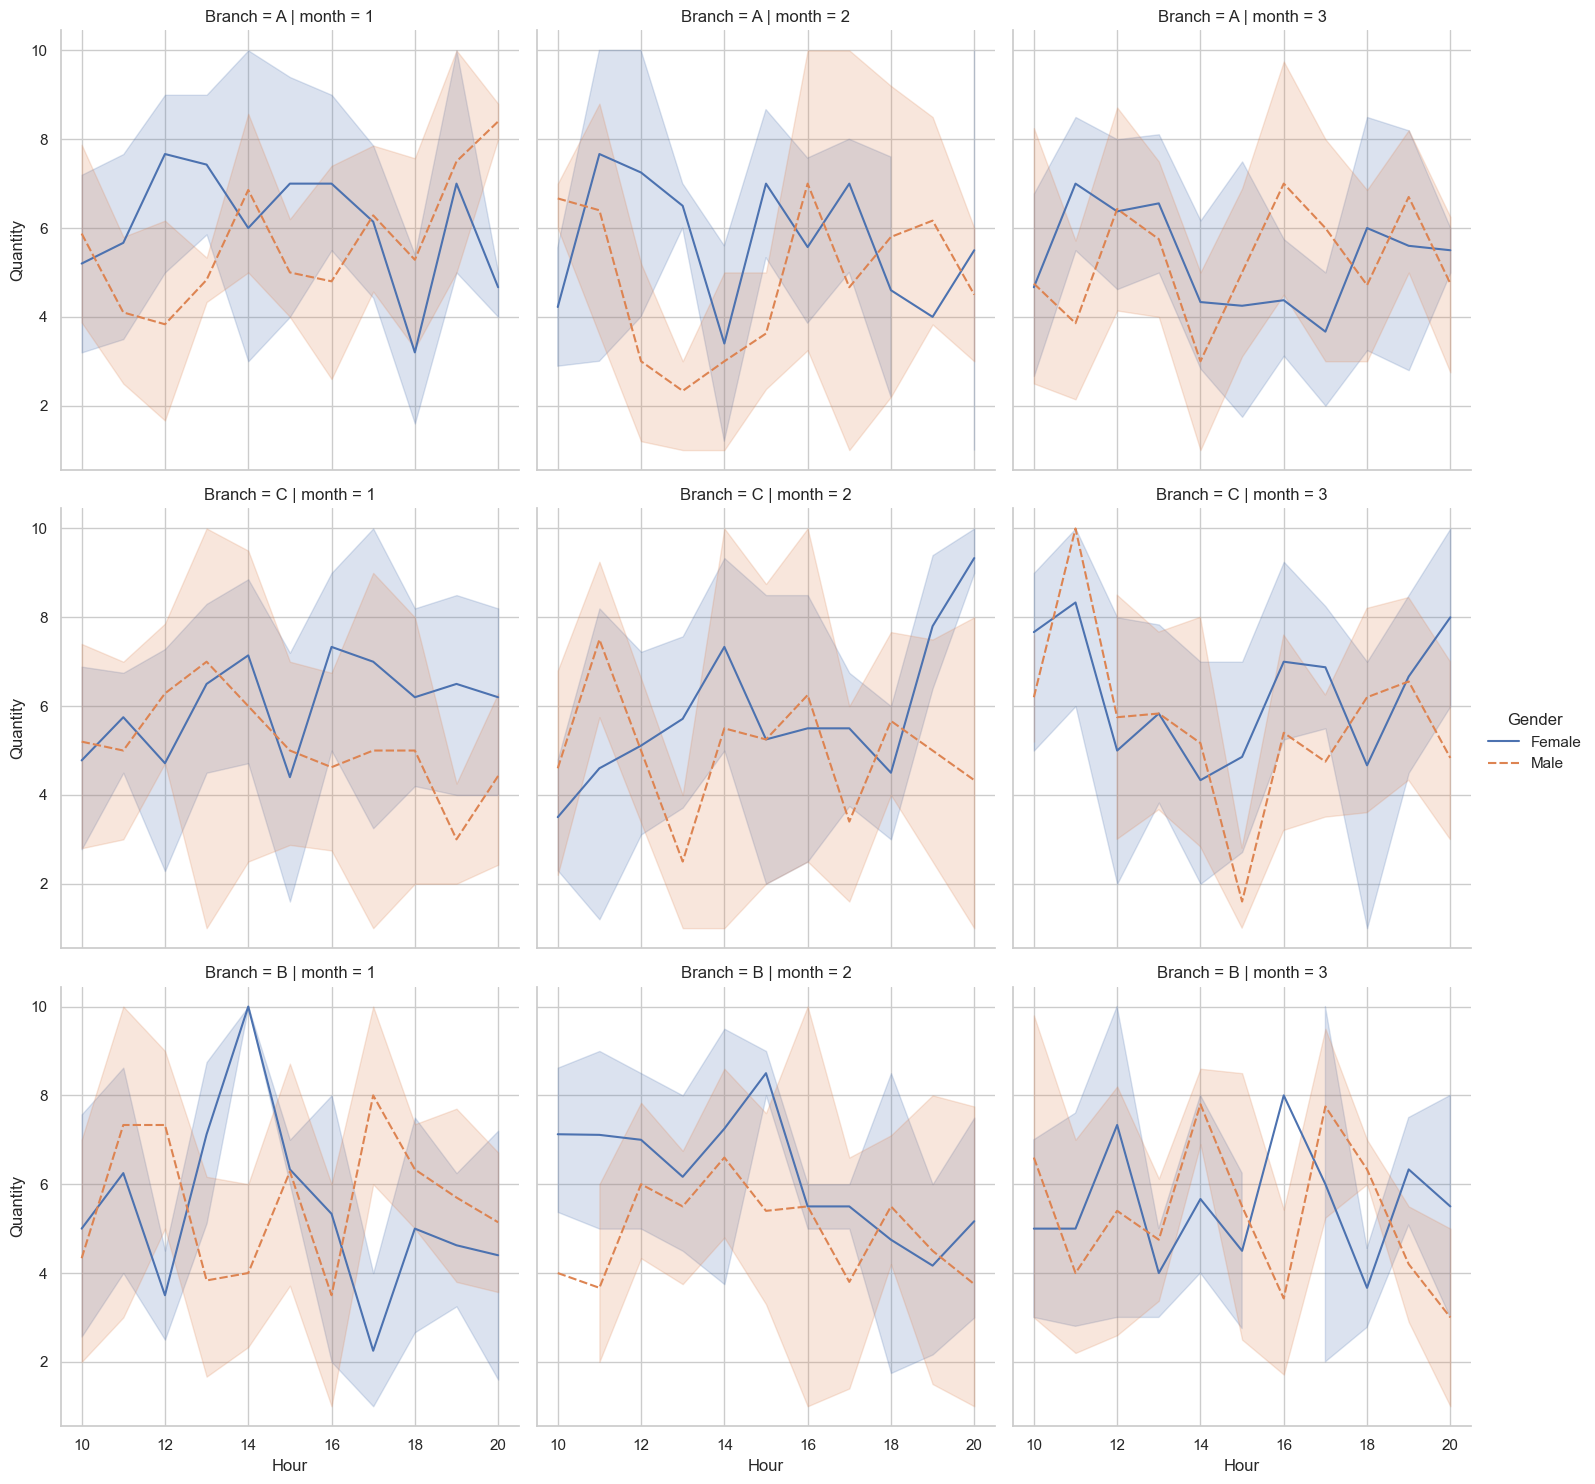

In [36]:
genderCount  = sns.relplot(x="Hour",  y = 'Quantity', col= 'month' , row= 'Branch', kind="line", hue="Gender", style="Gender", data =sales)

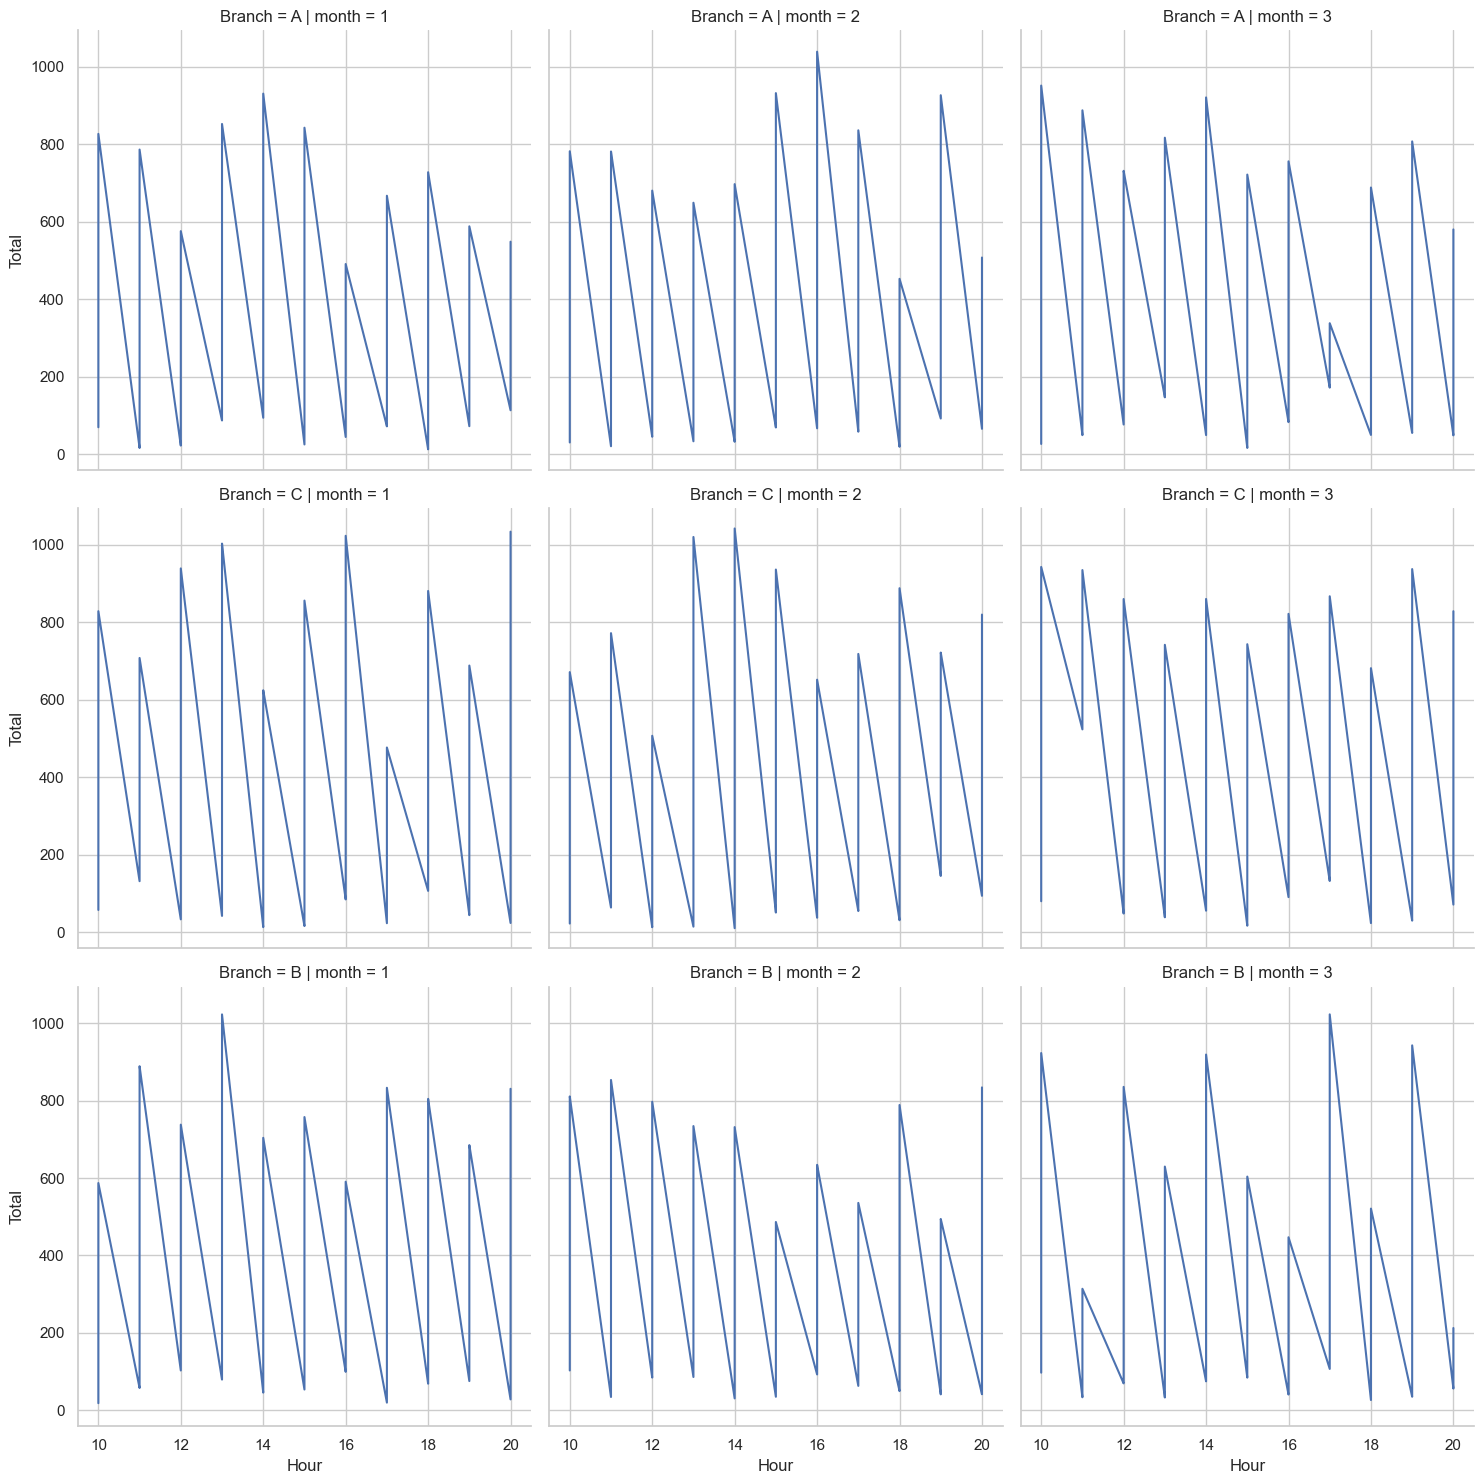

In [37]:
genderCount  = sns.relplot(x="Hour",  y = 'Total', col= 'month' , row= 'Branch', estimator = None, kind="line", data =sales)

In [38]:
sales['Rating'].unique()

array([ 9.1,  9.6,  7.4,  8.4,  5.3,  4.1,  5.8,  8. ,  7.2,  5.9,  4.5,
        6.8,  7.1,  8.2,  5.7,  4.6,  6.9,  8.6,  4.4,  4.8,  5.1,  9.9,
        6. ,  8.5,  6.7,  7.7,  7.5,  7. ,  4.7,  7.6,  7.9,  6.3,  5.6,
        9.5,  8.1,  6.5,  6.1,  6.6,  5.4,  9.3, 10. ,  6.4,  4.3,  4. ,
        8.7,  9.4,  5.5,  8.3,  7.3,  4.9,  4.2,  9.2,  7.8,  5.2,  9. ,
        8.8,  6.2,  9.8,  9.7,  5. ,  8.9])

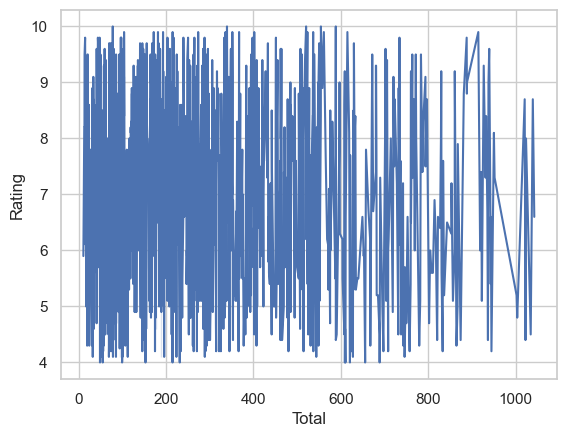

In [39]:
ageDisSpend = sns.lineplot(x="Total", y = "Rating", data =sales)

### Product Analysis

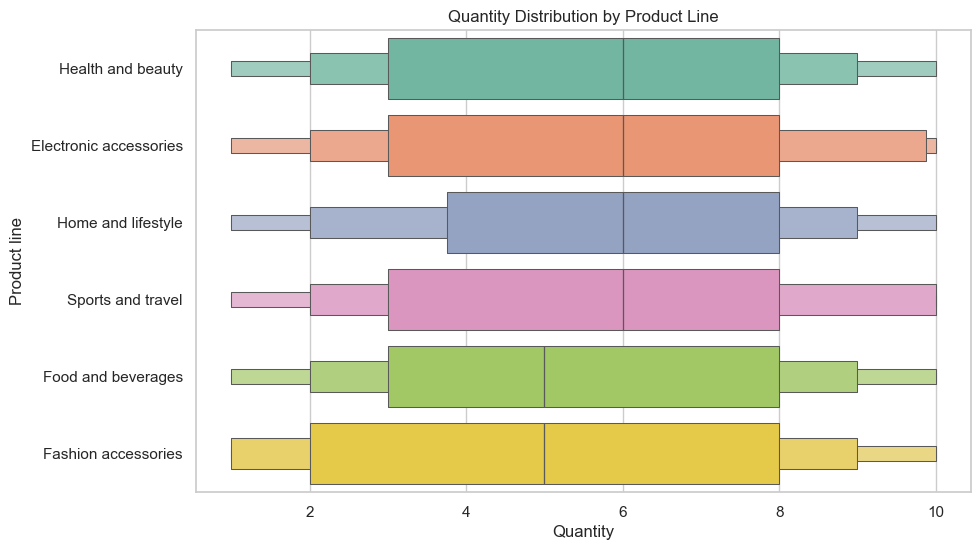

In [42]:
plt.figure(figsize=(10, 6))

sns.boxenplot(
    y="Product line",
    x="Quantity",
    hue="Product line",
    data=sales,
    palette="Set2",
    legend=False
)

plt.title("Quantity Distribution by Product Line")
plt.show()

From the above visual, Health and Beauty,Electronic accessories, Homem and lifestyle, Sports and travel have a better average quantity sales that food and beverages as well as Fashion accessories. 

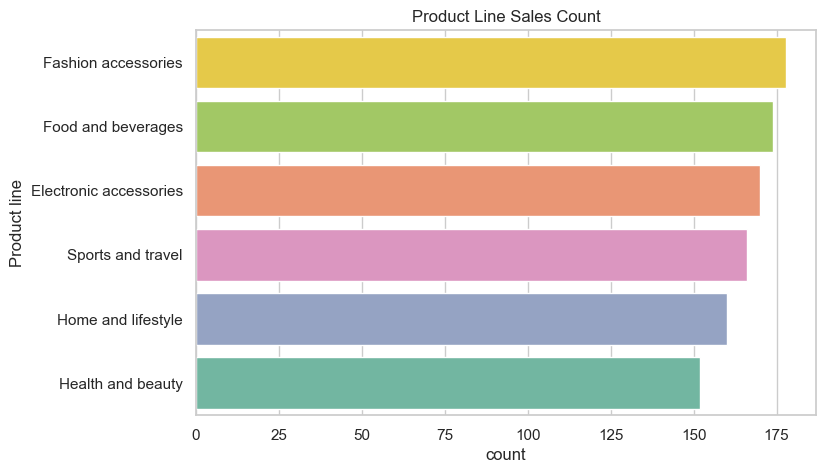

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Product line",
    data=sales,
    order=sales["Product line"].value_counts().index,
    hue="Product line",
    legend=False,
    palette="Set2"
)

plt.title("Product Line Sales Count")
plt.show()

From the above image shows the top product line item type sold in the given dataset. Fashion Accessories is the highest while Health and beauty is the lowest.

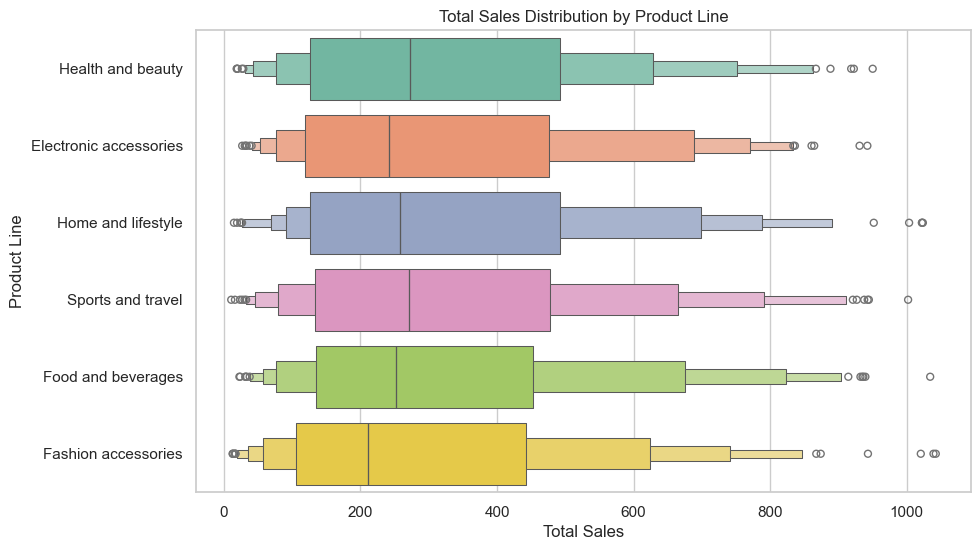

In [45]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    y="Product line",
    x="Total",
    data=sales,
    hue="Product line",
    palette="Set2",
    legend=False
)

plt.title("Total Sales Distribution by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.show()

<Axes: xlabel='Total', ylabel='Product line'>

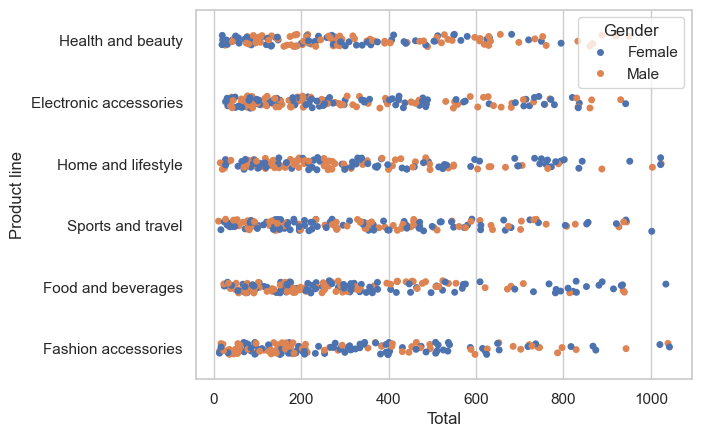

In [46]:
sns.stripplot(y = 'Product line', x = 'Total', hue = 'Gender', data=sales )

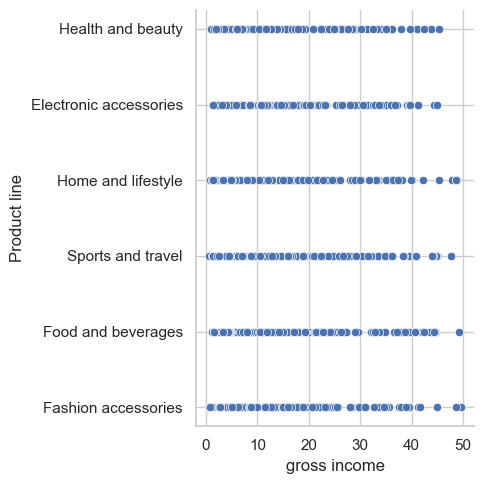

In [47]:
sns.relplot(y = 'Product line', x = 'gross income', data=sales )

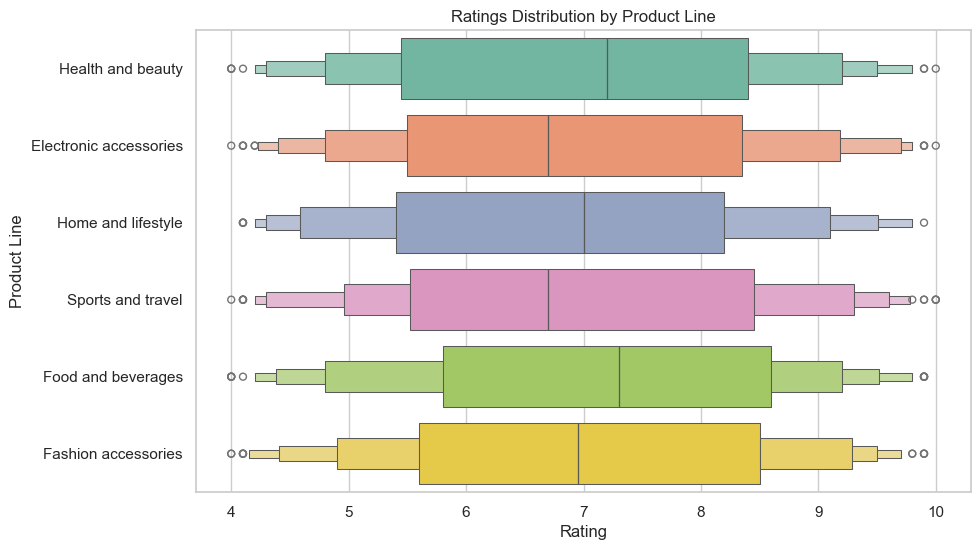

In [49]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    y="Product line",
    x="Rating",
    data=sales,
    hue="Product line",
    palette="Set2",
    legend=False
)

plt.title("Ratings Distribution by Product Line")
plt.xlabel("Rating")
plt.ylabel("Product Line")
plt.show()

Food and Beverages have the highest average rating while sports and travel the lowest.

### Let's see when customers buy certain products in the various branches. 

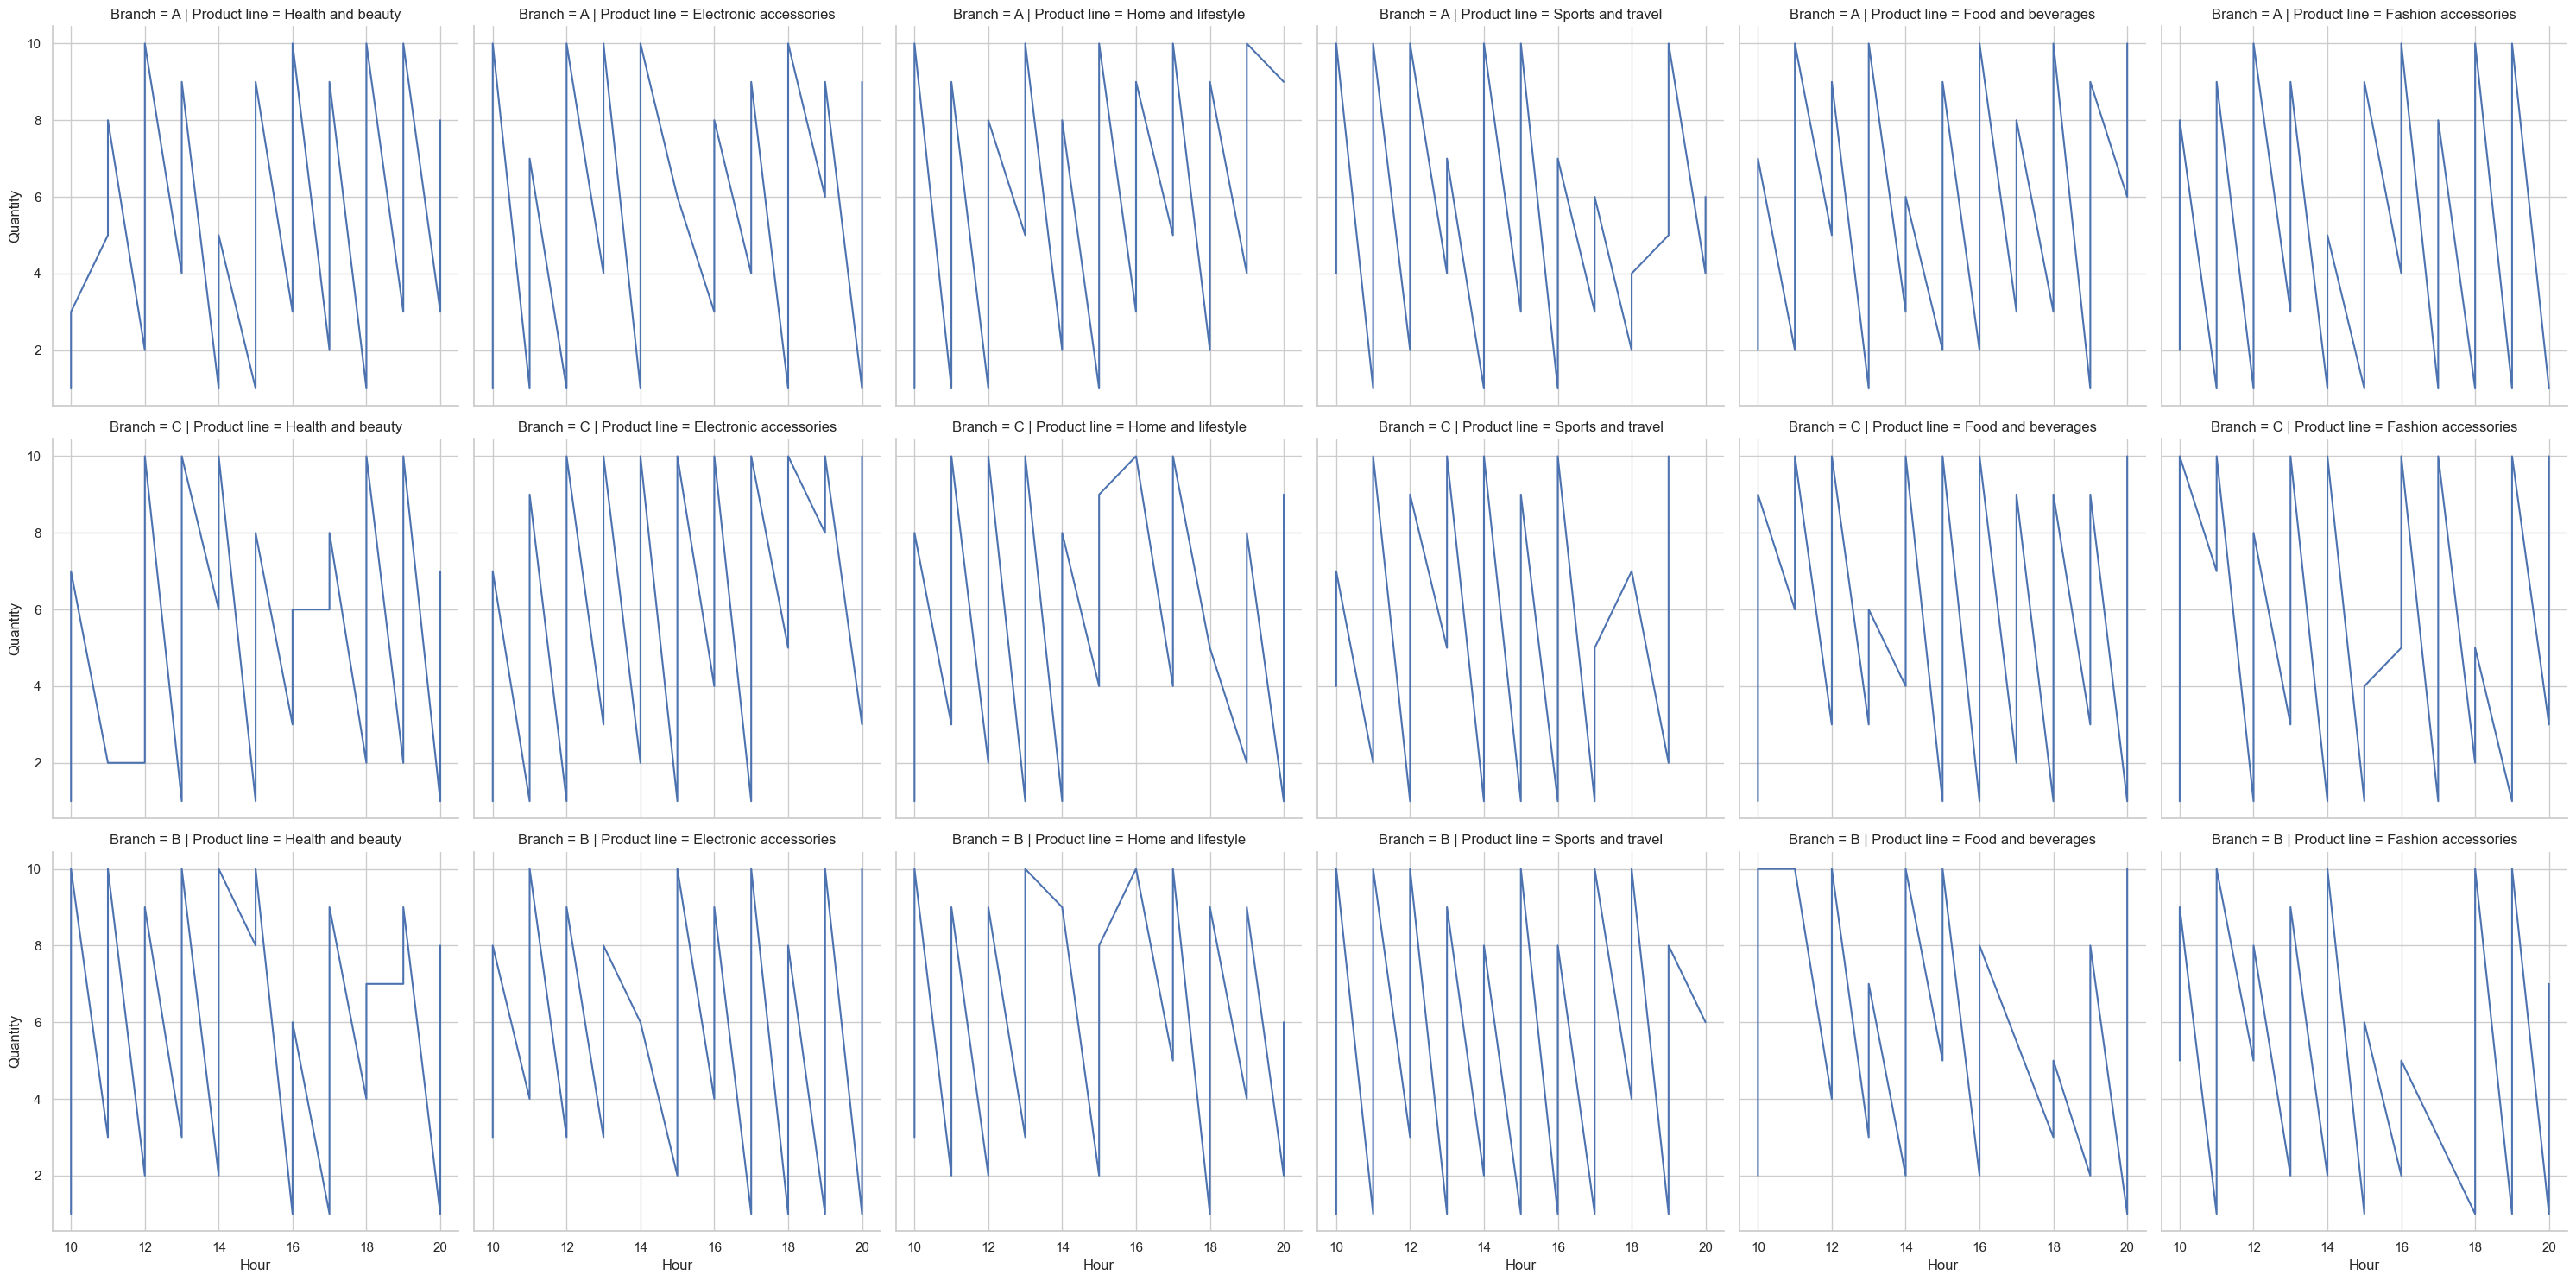

In [50]:
productCount  = sns.relplot(x="Hour",  y = 'Quantity', col= 'Product line' , row= 'Branch', estimator = None, kind="line", data =sales)

From the above plots, we can see that food and beverages sales usually high in all three branches at evening especially around 19:00.

## Payment Channel
Let see how customers make payment in this business

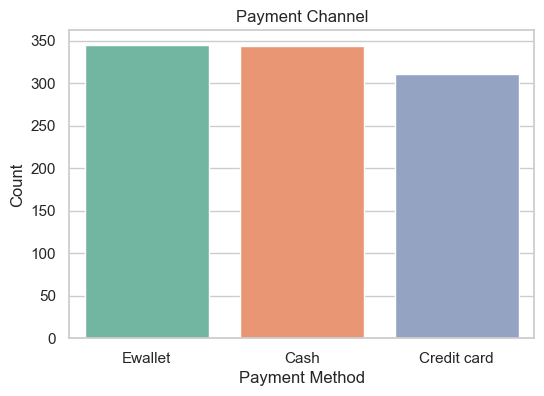

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Payment",
    data=sales,
    hue="Payment",
    palette="Set2",
    legend=False
)

plt.title("Payment Channel")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

Most of the customers pay through the Ewallet and Cash Payment while under 40 percent of them pay with their credit card. We would also like to see this payment type distribution across all the branches.

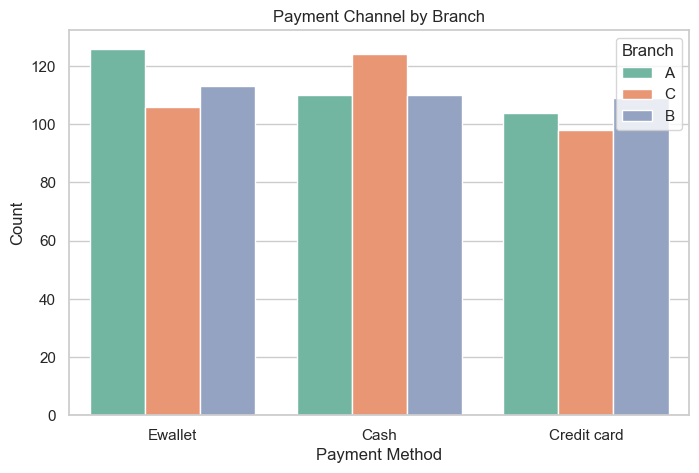

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Payment",
    hue="Branch",
    data=sales,
    palette="Set2"
)

plt.title("Payment Channel by Branch")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

## Customer Analysis
From inspection, there are two types of customers. Members and Normal. Let's see how many they are and where they are 

In [53]:
sales['Customer type'].nunique()

2

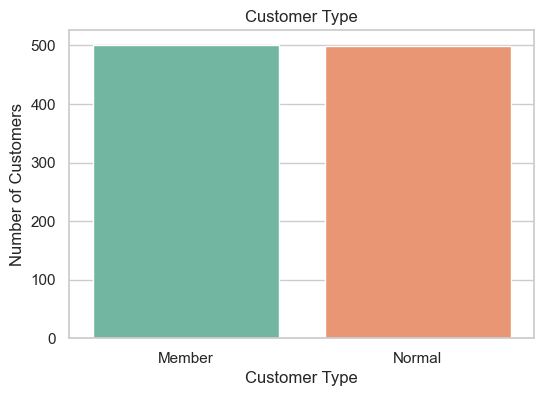

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Customer type",
    data=sales,
    hue="Customer type",
    palette="Set2",
    legend=False
)

plt.title("Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

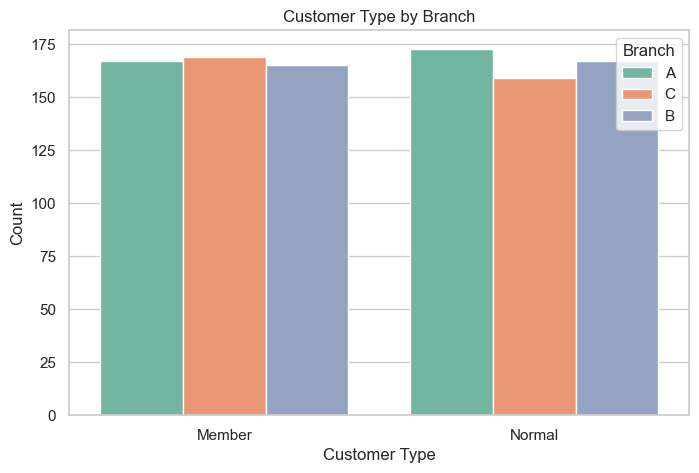

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Customer type",
    hue="Branch",
    data=sales,
    palette="Set2"
)

plt.title("Customer Type by Branch")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

In [56]:
sales.groupby(['Customer type']).agg({'Total': 'sum'})

,Total
Customer type,
Member,164223.444
Normal,158743.305


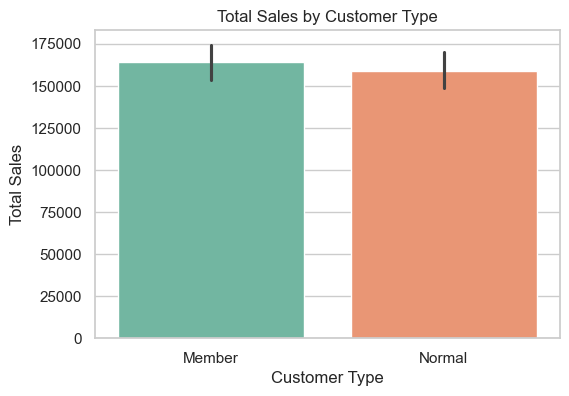

In [57]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Customer type",
    y="Total",
    estimator=sum,
    data=sales,
    hue="Customer type",
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.show()

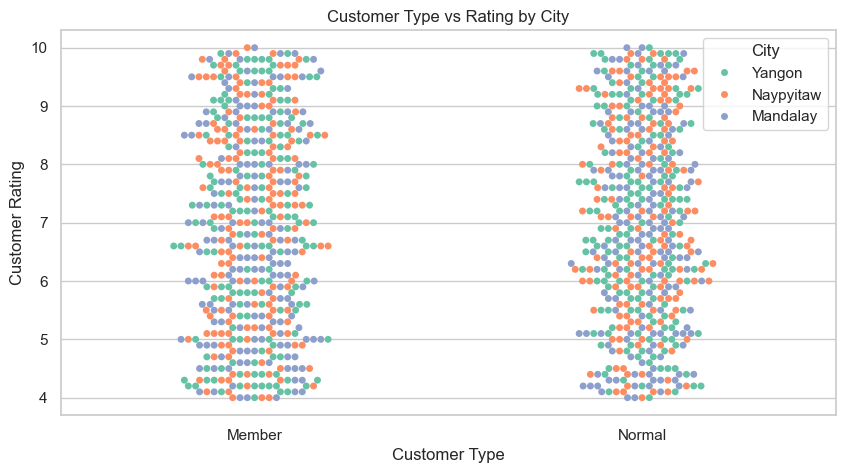

In [59]:
plt.figure(figsize=(10,5))

sns.swarmplot(
    x="Customer type",
    y="Rating",
    hue="City",
    data=sales,
    palette="Set2"
)

plt.title("Customer Type vs Rating by City")
plt.xlabel("Customer Type")
plt.ylabel("Customer Rating")
plt.show()

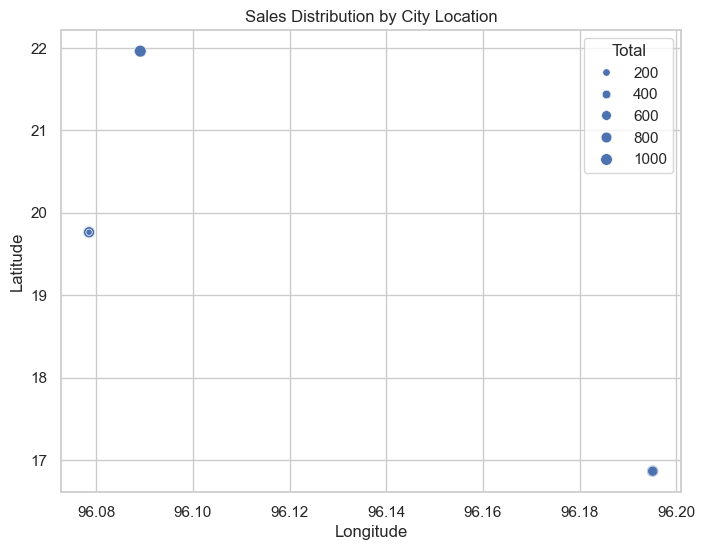

In [62]:
long = {
    "Yangon": 96.1951,
    "Naypyitaw": 96.0785,
    "Mandalay": 96.0891
}

lat = {
    "Yangon": 16.8661,
    "Naypyitaw": 19.7633,
    "Mandalay": 21.9588
}

# Map coordinates to cities
sales["long"] = sales["City"].map(long)
sales["lat"] = sales["City"].map(lat)

# Scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="long",
    y="lat",
    size="Total",
    data=sales,
    legend="brief"
)

plt.title("Sales Distribution by City Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

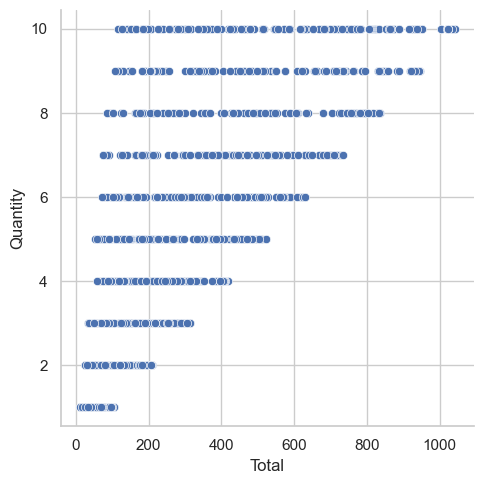

In [63]:
 sns.relplot(x="Total",  y = "Quantity", data =sales)


## Business Key Performance Indicators (KPIs)

The following KPIs provide a summary of the supermarket's overall sales performance, customer behavior, and product performance.

### 1. Total Revenue

In [10]:
# Total Revenue
total_revenue = sales['Total'].sum()
print(f"Total Revenue: {total_revenue:.2f}")

Total Revenue: 322966.75


### 2. Total Transactions

In [11]:
# Total Transactions
total_transactions = sales.shape[0]
print(f"Total Transactions: {total_transactions}")

Total Transactions: 1000


### 3. Average Order Value

In [12]:
# Average Order Value
avg_order = sales['Total'].mean()
print(f"Average Order Value: {avg_order:.2f}")

Average Order Value: 322.97


### 4. Total Gross Income

In [13]:
# Total Gross Income
gross_income = sales['gross income'].sum()
print(f"Total Gross Income: {gross_income:.2f}")

Total Gross Income: 15379.37


### 5. Average Customer Rating

In [14]:
# Average Customer Rating
avg_rating = sales['Rating'].mean()
print(f"Average Rating: {avg_rating:.2f}")

Average Rating: 6.97


### 6. Highest Revenue Branch

In [15]:
# Highest Revenue Branch
branch_sales = sales.groupby('Branch')['Total'].sum()

print(branch_sales)

print("\nHighest Revenue Branch:")
print(branch_sales.idxmax())

Branch
A    106200.3705
B    106197.6720
C    110568.7065
Name: Total, dtype: float64

Highest Revenue Branch:
C


### 7. Best Selling Product Line

In [16]:
# Best Selling Product Line
product_sales = sales.groupby('Product line')['Total'].sum()

print(product_sales)

print("\nBest Selling Product Line:")
print(product_sales.idxmax())

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64

Best Selling Product Line:
Food and beverages


### 8. Most Preferred Payment Method

In [17]:
# Most Preferred Payment Method
payment = sales['Payment'].value_counts()

print(payment)

print("\nMost Preferred Payment Method:")
print(payment.idxmax())

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

Most Preferred Payment Method:
Ewallet


### 9. Customer Type Revenue

In [18]:
# Customer Type Revenue
customer = sales.groupby('Customer type')['Total'].sum()

print(customer)

print("\nHighest Spending Customer Type:")
print(customer.idxmax())

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64

Highest Spending Customer Type:
Member


### 10. Gender-wise Revenue

In [19]:
# Gender-wise Revenue
gender = sales.groupby('Gender')['Total'].sum()

print(gender)

Gender
Female    167882.925
Male      155083.824
Name: Total, dtype: float64


### 11. Average Quantity

In [20]:
# Average Quantity
avg_quantity = sales['Quantity'].mean()

print(f"Average Quantity Purchased: {avg_quantity:.2f}")

Average Quantity Purchased: 5.51


### 12. Highest Rated Product

In [21]:
# Highest Rated Product
rating = sales.groupby('Product line')['Rating'].mean()

print(rating)

print("\nHighest Rated Product Line:")
print(rating.idxmax())

Product line
Electronic accessories    6.924706
Fashion accessories       7.029213
Food and beverages        7.113218
Health and beauty         7.003289
Home and lifestyle        6.837500
Sports and travel         6.916265
Name: Rating, dtype: float64

Highest Rated Product Line:
Food and beverages


### 13. Revenue by City

In [22]:
# Revenue by City
city = sales.groupby('City')['Total'].sum()

print(city)

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Total, dtype: float64


### 14. Revenue by Month

In [23]:
# Revenue by Month
sales['Date'] = pd.to_datetime(sales['Date'])
sales['Month'] = sales['Date'].dt.month_name()

monthly = sales.groupby('Month')['Total'].sum()

print(monthly)

Month
February     97219.374
January     116291.868
March       109455.507
Name: Total, dtype: float64


### 15. Peak Sales Hour

In [25]:
# Peak Sales Hour
sales['Hour'] = pd.to_datetime(sales['Time'], format='%H:%M').dt.hour

hour_sales = sales.groupby('Hour')['Total'].sum()

print(hour_sales)

print("\nPeak Sales Hour:")
print(hour_sales.idxmax())

Hour
10    31421.4810
11    30377.3295
12    26065.8825
13    34723.2270
14    30828.3990
15    31179.5085
16    25226.3235
17    24445.2180
18    26030.3400
19    39699.5130
20    22969.5270
Name: Total, dtype: float64

Peak Sales Hour:
19


### Correlation Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

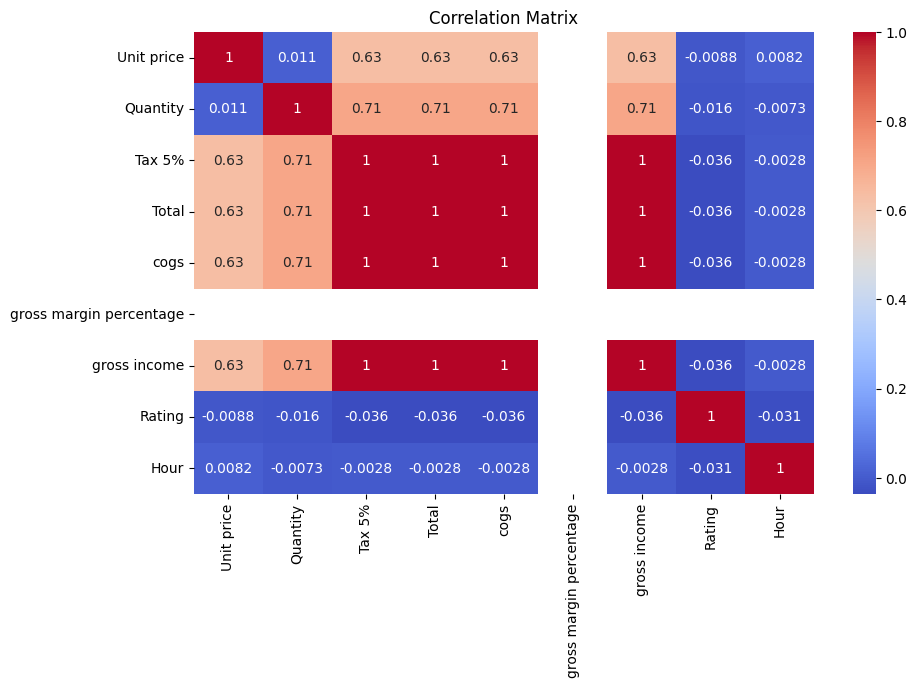

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(sales.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")

The correlation heatmap shows that Total Sales, Tax (5%), and Gross Income are highly positively correlated, while Customer Rating has a weak correlation with sales. This indicates that revenue and profit are closely related, whereas customer ratings have minimal influence on transaction value.

### PairPlot

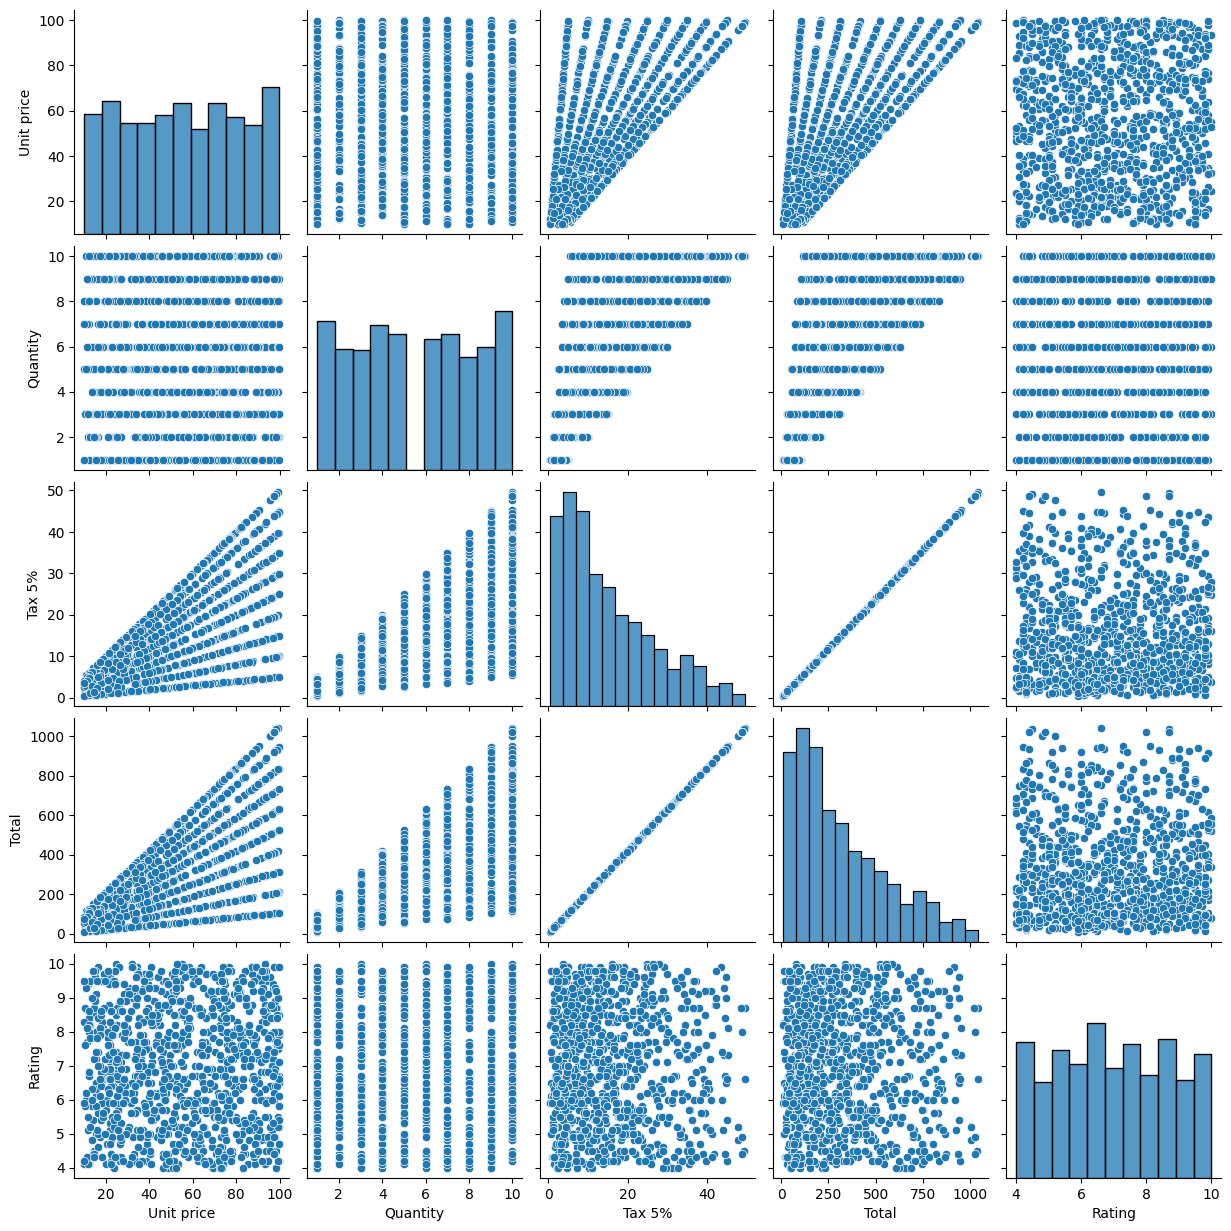

In [27]:
sns.pairplot(
    sales[
        ['Unit price',
         'Quantity',
         'Tax 5%',
         'Total',
         'Rating']
    ]
)

The pair plot shows that Total and Tax (5%) are strongly positively related, while Quantity also contributes to higher sales. Customer Rating has no strong relationship with sales-related variables, indicating that transaction value is largely independent of customer ratings.

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


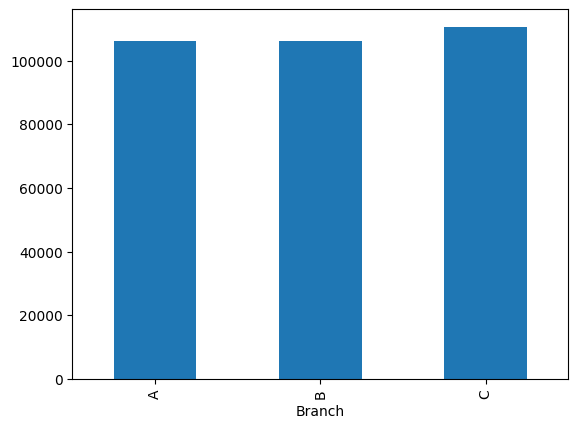

In [30]:
branch = sales.groupby('Branch')['Total'].sum()

branch.plot(kind='bar')
print(branch.sort_values(ascending=False))

Branch C generated the highest revenue while Branch A generated the lowest.

## Conclusion

• Branch C generated the highest revenue.

• Food and Beverages contributed the largest share of sales.

• Electronic Wallet was the most preferred payment method.

• Evening hours experienced maximum customer traffic.

• Members spent more than normal customers.

• Female customers purchased slightly more products.

========================================
      SUPERMARKET SALES KPI DASHBOARD
========================================

Total Revenue           : 322966.75
Total Transactions      : 1000
Average Order Value     : 322.97
Total Gross Income      : 15379.37
Average Customer Rating : 6.97

Highest Revenue Branch  : C
Best Selling Product    : Food and Beverages
Most Preferred Payment  : Ewallet
Highest Revenue Customer: Member
Peak Sales Hour         : 19:00